# OpenMesh - New York City

Links of the community-run NYC Mesh wireless network, Weather Underground
personal weather stations (PWS) and airport ASOS stations, January 2024.
Jacoby et al. (2026), [ESSD 18, 5817-5836](https://doi.org/10.5194/essd-18-5817-2026): CML [doi:10.5281/zenodo.15287692](https://doi.org/10.5281/zenodo.15287692)
(CC BY 4.0), PWS [doi:10.5281/zenodo.17508286](https://doi.org/10.5281/zenodo.17508286)
(CC BY-NC 4.0). Source code for building the subsets:
[drorjac/OpenMesh](https://github.com/drorjac/OpenMesh); in this repository,
`projects/openmesh_nyc/`.

The example folder
([`OpenMesh/`](https://github.com/OpenSenseAction/opensense_example_data/tree/main/OpenMesh))
has three durations. ASOS is published for `20d` only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import poligrain as plg

from core import viz_style as vs
from core.opensense import example_data, plots

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)

In [2]:
for subset in ("1d", "1w", "20d"):
    d = example_data.load("openmesh", subset, verbose=False)
    span = f"{pd.Timestamp(d['cml'].time.values[0]):%Y-%m-%d} .. {pd.Timestamp(d['cml'].time.values[-1]):%Y-%m-%d}"
    print(f"{subset:4s} {span}   " + "   ".join(f"{k}: {dict(v.sizes)}" for k, v in d.items()))

1d   2024-01-15 .. 2024-01-16   cml: {'cml_id': 75, 'sublink_id': 3, 'time': 1441}   pws: {'id': 35, 'time': 287}


1w   2024-01-15 .. 2024-01-22   cml: {'cml_id': 75, 'sublink_id': 3, 'time': 10081}   pws: {'id': 35, 'time': 2012}


20d  2024-01-12 .. 2024-02-01   cml: {'cml_id': 75, 'sublink_id': 3, 'time': 28801}   pws: {'id': 37, 'time': 5552}   asos: {'time': 28266, 'id': 4}


In [3]:
data = example_data.load("openmesh", "20d", verbose=False)
cml, pws, asos = data["cml"], data["pws"], data["asos"]
cml

<xarray.Dataset> Size: 26MB
Dimensions:        (cml_id: 75, sublink_id: 3, time: 28801)
Coordinates: (12/18)
  * time           (time) datetime64[ns] 230kB 2024-01-12 ... 2024-02-01
  * sublink_id     (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat     (cml_id) float32 300B 40.7 40.66 40.73 ... 40.66 40.73 40.65
    site_0_lon     (cml_id) float32 300B -73.94 -74.0 -73.95 ... -73.95 -74.0
    site_1_lat     (cml_id) float32 300B 40.69 40.68 40.72 ... 40.66 40.73 40.64
    site_1_lon     (cml_id) float32 300B -73.92 -73.99 -73.98 ... -73.95 -73.95
    ...             ...
    site_0_x       (cml_id) float64 600B 5.896e+05 5.841e+05 ... 5.845e+05
    site_0_y       (cml_id) float64 600B 4.506e+06 4.501e+06 ... 4.5e+06
    site_1_x       (cml_id) float64 600B 5.915e+05 5.85e+05 ... 5.888e+05
    site_1_y       (cml_id) float64 600B 4.504e+06 4.504e+06 ... 4.499e+06
    x              (cml_id) float64 600B 5.905e+05 5.846e+05 ... 5.866e+05
    y              (cml_id) float64 600B 4.505e+06 4.503e+06 ... 4.499e+06
Data variables:
    rsl            (cml_id, sublink_id, time) float32 26MB -49.0 -49.0 ... nan
Attributes: (12/15)
    title:                 OpenMesh CML sample (20d), start 2024-01-12
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:                Community NYC Mesh Wireless Network
    history:               2025-11-01: Updated metadata, converted netCDF → O...
    ...                    ...
    comment:               OpenMesh: Wireless Signal Dataset for Opportunisti...
    Conventions:           OpenSense-CML-v1.0
    start_date:            2024-01-12
    end_date:              2024-02-01
    time_range:            2024-01-12T00:00:00 / 2024-02-01T00:00:00
    cml_subset:            all

## How the links differ from OpenMRG and OpenRainER

**Received power only.** There is no `tsl`, so path loss is `-rsl` up to a
constant, and a retrieval written for `tsl - rsl` needs a branch for it
(`retrieval.total_loss_from`).

**Up to three sublinks per link, on different bands.** Most links report one
sublink; the others are the two directions of one band or a second band.
Rain attenuation grows steeply with frequency: a short 5-6 GHz link barely
sees rain, while at 58-69 GHz even a sub-kilometre link does.

In [4]:
freq = cml.frequency_ghz.values
has_data = cml.rsl.notnull().any("time").values
bands = pd.cut(pd.Series(freq[has_data]), [0, 7, 30, 100], labels=["5-6 GHz", "24 GHz", "58-69 GHz"])
per_link = has_data.sum(axis=1)
print("variables       :", list(cml.data_vars))
print("sublinks / link :", {int(k): int(v) for k, v in zip(*np.unique(per_link, return_counts=True))},
      "(sublinks with data -> number of links)")
print("sublinks / band :", bands.value_counts().to_dict())
print(f"lengths         : {float(cml.length_km.min()):.3f} .. {float(cml.length_km.max()):.2f} km")
avail = cml.rsl.notnull().mean("time").values[has_data]
print(f"availability    : median {np.median(avail) * 100:.0f}% per sublink")

variables       : ['rsl']
sublinks / link : {0: 1, 1: 51, 2: 20, 3: 3} (sublinks with data -> number of links)
sublinks / band : {'5-6 GHz': 56, '58-69 GHz': 36, '24 GHz': 8}
lengths         : 0.025 .. 6.94 km
availability    : median 100% per sublink


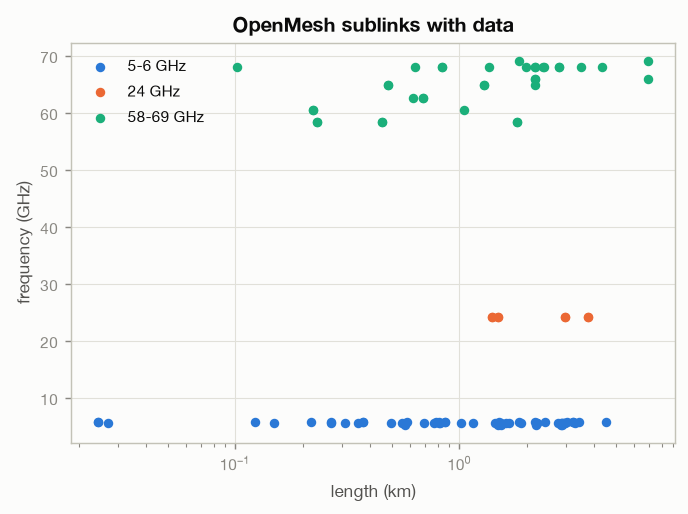

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, c in zip(["5-6 GHz", "24 GHz", "58-69 GHz"], (C1, C2, C3)):
    m = (bands == label).values
    ax.scatter(np.broadcast_to(cml.length_km.values[:, None], freq.shape)[has_data][m],
               freq[has_data][m], s=18, color=c, label=label)
ax.set(xscale="log", xlabel="length (km)", ylabel="frequency (GHz)",
       title="OpenMesh sublinks with data")
ax.legend();

## The network with PWS and ASOS

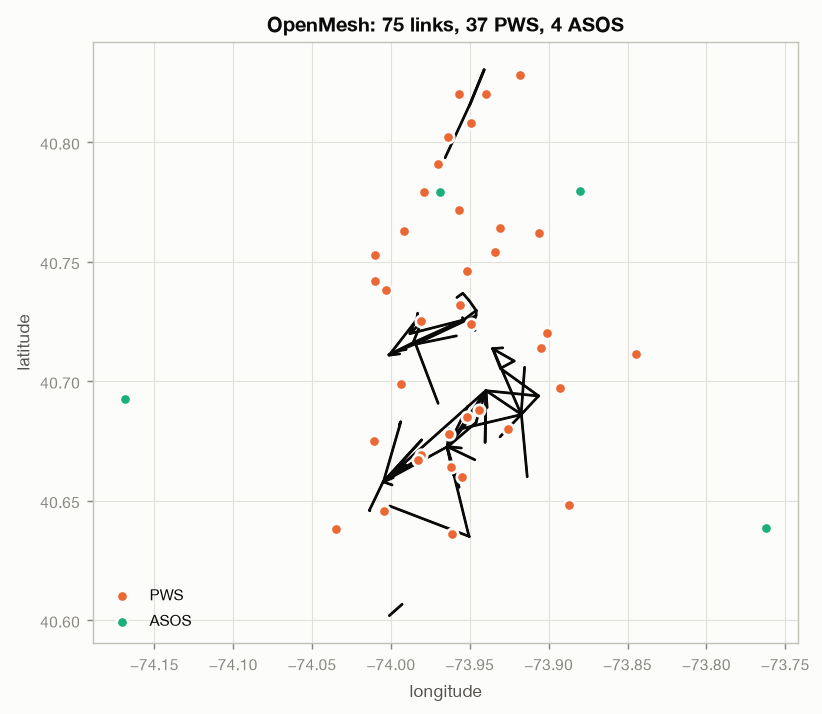

In [6]:
plots.network(None, cml, gauges={"PWS": pws, "ASOS": asos},
              title=f"OpenMesh: {cml.sizes['cml_id']} links, {pws.sizes['id']} PWS, "
                    f"{asos.sizes['id']} ASOS");

## 20 days, three sensors

ASOS rain rate at each airport, the median PWS rain rate, and the received
level of the link with the widest signal range. The PWS temperature tells
rain from snow: on 16-17 January, below freezing, ASOS and the link both see
precipitation while the PWS median stays at zero - an unheated tipping bucket
does not record snow.

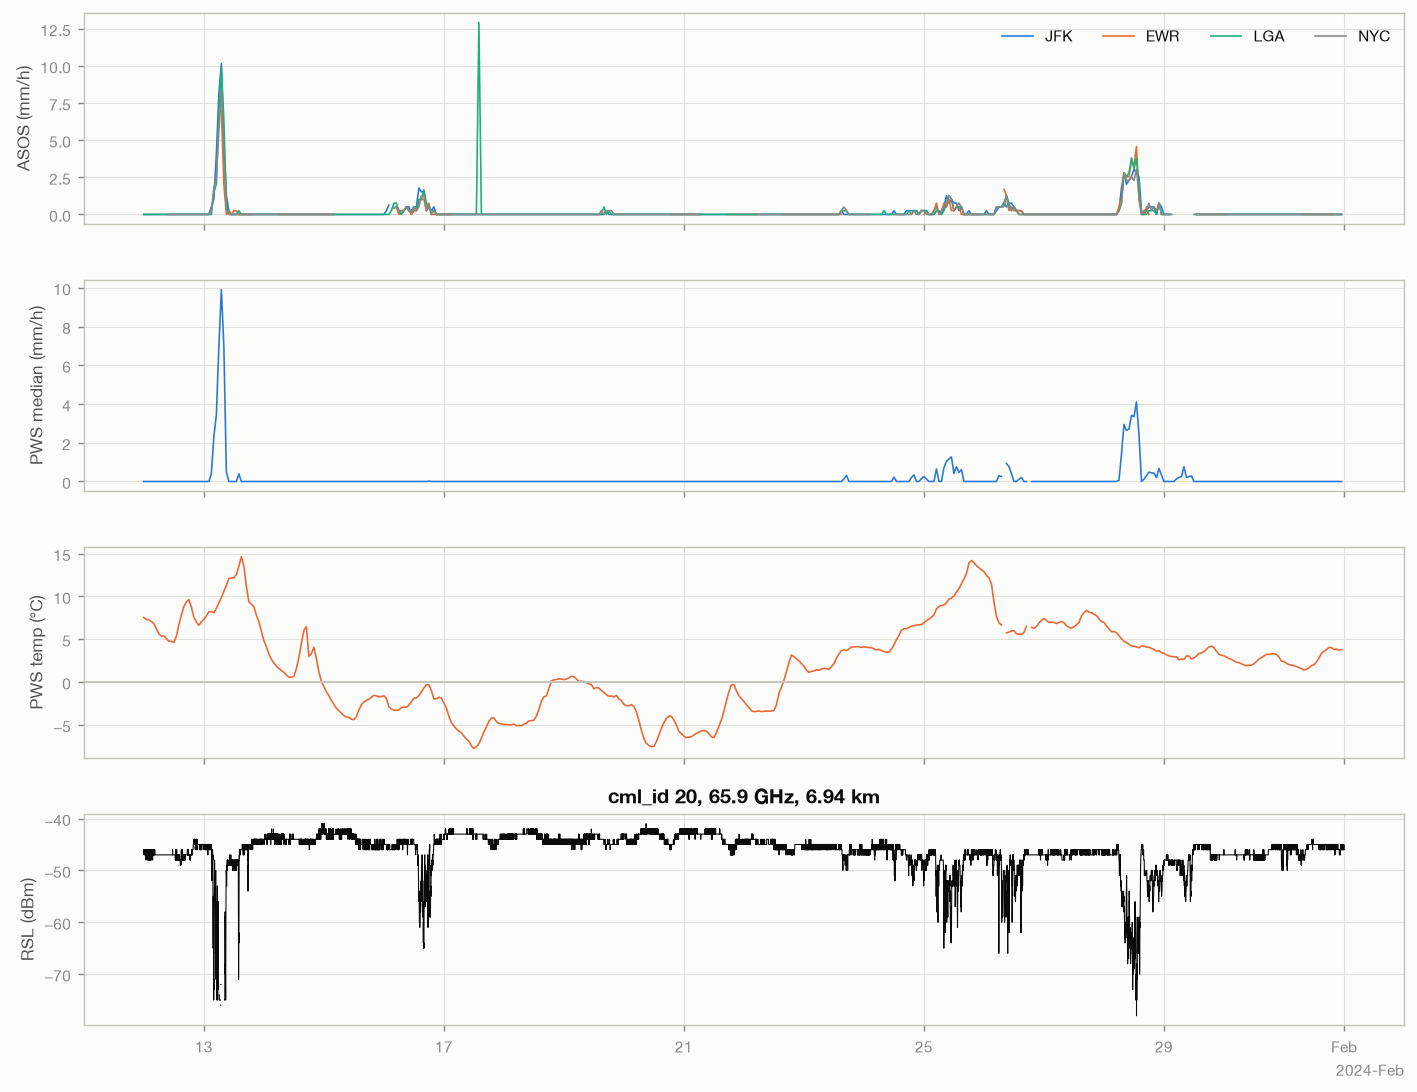

In [7]:
link_i, sub_i = np.unravel_index(np.nanargmax((cml.rsl.max("time") - cml.rsl.min("time")).values),
                                 freq.shape)
fig, axes = plt.subplots(4, 1, figsize=(11, 8.5), sharex=True)
for s, c in zip(asos.id.values, (C1, C2, C3, vs.INK_MUTED)):
    asos.R.sel(id=s).resample(time="1h").mean().plot(ax=axes[0], color=c, lw=0.9, label=str(s))
axes[0].set(ylabel="ASOS (mm/h)", title="", xlabel=""); axes[0].legend(ncol=4)
pws.R.resample(time="1h").mean().median("id").plot(ax=axes[1], color=C1, lw=0.9)
axes[1].set(ylabel="PWS median (mm/h)", title="", xlabel="")
pws.temperature.resample(time="1h").mean().median("id").plot(ax=axes[2], color=C2, lw=0.9)
axes[2].axhline(0, color=vs.BASELINE, lw=1)
axes[2].set(ylabel="PWS temp (°C)", title="", xlabel="")
cml.rsl.isel(cml_id=link_i, sublink_id=sub_i).plot(ax=axes[3], color=vs.INK_PRIMARY, lw=0.6)
axes[3].set(ylabel="RSL (dBm)", xlabel="",
            title=f"cml_id {cml.cml_id.values[link_i]}, {freq[link_i, sub_i]:.1f} GHz, "
                  f"{float(cml.length_km[link_i]):.2f} km")
fig.tight_layout()

## PWS quality control

Crowd-sourced gauges fail in ways a single station cannot reveal.
`core.opensense.pws_qc` runs the `pypwsqc` neighbour checks (faulty zeros,
high influx, station outlier) plus a rate/amount consistency check. The
station-outlier filter needs a long record, so for 20 days the evaluation
window is shortened to a week.

In [8]:
from core.opensense import pws_qc

qc = pws_qc.flag(pws, so_evaluation_period=2016, so_mmatch=30)
table = pws_qc.summary(qc)
print(f"{len(pws_qc.usable(qc))} of {pws.sizes['id']} stations usable as references")
table.tail(10).round(3)

22 of 37 stations usable as references


,missing,fz,hi,so,rate,so_evaluated,total_mm,total_qc_mm
station,,,,,,,,
KNYNEWYO1120,0.061,0.0,0.000,0.000,0.000,0.384,69.088,69.088
KNYNEWYO1533,0.073,0.0,0.000,0.000,0.000,0.386,72.898,72.898
KNYNEWYO1053,0.106,0.0,0.000,0.000,0.000,0.384,74.930,74.930
KNYNEWYO1591,0.061,0.0,0.000,0.000,0.000,0.388,76.454,76.454
KNYNEWYO1805,0.505,0.0,0.001,0.091,0.000,0.339,188.468,78.486
KNYNEWYO1796,0.061,0.0,0.000,0.000,0.000,0.386,79.248,79.248
KNYNEWYO1313,0.062,0.0,0.000,0.000,0.000,0.388,80.518,80.518
KNYNEWYO1288,0.267,0.0,0.000,0.000,0.000,0.385,82.296,82.296
KNYNEWYO1824,0.120,0.0,0.000,0.000,0.000,0.388,83.058,83.058
